In [1]:
!date

Tue Mar  3 17:48:24 CET 2026


In [2]:
pwd

'/Users/aidasaglinskas/Desktop/ANDSpeak/Google_drive_things/Code-2026'

In [3]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
def pretty_barplot(vec1, vec2, labels=("Group 1", "Group 2"), 
                   ylabel="Value", title=None):
    
    """
    Plots outline-only bar plot with SEM error bars and overlaid individual data points.

    Parameters
    ----------
    vec1, vec2 : array-like
        Numeric vectors of values.
    labels : tuple
        Labels for the two groups.
    ylabel : str
        Y-axis label.
    title : str or None
        Optional plot title.
    """

    # Convert to numpy arrays
    vec1 = np.asarray(vec1)
    vec2 = np.asarray(vec2)

    # Means
    means = [vec1.mean(), vec2.mean()]

    # Standard Error of the Mean
    sems = [
        vec1.std(ddof=1) / np.sqrt(len(vec1)),
        vec2.std(ddof=1) / np.sqrt(len(vec2))
    ]

    # Create figure
    fig, ax = plt.subplots(figsize=(6, 5))

    x = np.arange(2)

    # Outline-only bars
    ax.bar(
        x, means,
        yerr=sems,
        capsize=6,
        facecolor='none',
        edgecolor='black',
        linewidth=2,
        width=0.6,
        error_kw=dict(linewidth=2)
    )

    # Jittered scatter of individual data points
    jitter_strength = 0.05
    ax.scatter(
        np.random.normal(x[0], jitter_strength, size=len(vec1)),
        vec1,
        color='black',
        alpha=0.7,
        s=50,
        zorder=3
    )

    ax.scatter(
        np.random.normal(x[1], jitter_strength, size=len(vec2)),
        vec2,
        color='black',
        alpha=0.7,
        s=50,
        zorder=3
    )

    # Styling
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12)
    #ax.set_ylabel(ylabel, fontsize=13)
    plt.title(ylabel,fontsize=13)
    if title:
        ax.set_title(title, fontsize=14)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=11)

    t,p = stats.ttest_ind(vec1,vec2)
    degf = len(vec1)+len(vec2)-2
    delta = (vec1.mean()-vec2.mean()).round(2)
    if p<.001:
        tstring = f'ΔM={delta}, t({degf})={t:.2f},p<.001'
    else:
        tstring = f'ΔM={delta}, t({degf})={t:.2f},p={p:.2f}'

    ax.set_xlabel(tstring, fontsize=13)

    plt.tight_layout()
    plt.show()

In [5]:
df = pd.read_csv('../DementiaBank-preprocessed2/file_list_annot_v2.csv')
idx1 = df['has_disvoice_f'].values
idx2 = df['has_complexity_f'].values

df = df.iloc[idx1*idx2]
df.sample(10)

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,path,site,group,filename,diag,subName,size_MB,dur_s,dur_m,speaker_text_len,has_complexity_f,has_disvoice_f,num_audio_files,sum_audio_len
238,238,238,14,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Delaware,dementia,78-1.mp3,D,Delaware_D_78,3.51,413.36,6.889333,3176,True,True,33,215.450
225,225,225,1,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Delaware,dementia,58-1.mp3,D,Delaware_D_58,3.28,449.96,7.499333,3760,True,True,32,300.149
96,96,96,23,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Pitt,control,296-0.mp3,C,Pitt_C_296,0.99,64.88,1.081333,454,True,True,6,38.351
215,215,215,25,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Delaware,control,90-1.mp3,C,Delaware_C_90,4.98,521.82,8.697000,4283,True,True,39,326.551
251,251,251,27,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Delaware,dementia,46-1.mp3,D,Delaware_D_46,10.03,657.18,10.953000,3927,True,True,56,350.051
31,31,31,31,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Pitt,dementia,053-1.mp3,D,Pitt_D_053,2.01,131.67,2.194500,910,True,True,6,36.750
175,175,175,13,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Lu,dementia,F13.mp3,D,Lu_D_F13,1.06,69.54,1.159000,370,True,True,7,40.851
90,90,90,17,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Pitt,control,678-0.mp3,C,Pitt_C_678,1.28,83.61,1.393500,494,True,True,5,27.400
283,283,283,59,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Delaware,dementia,11-1.mp3,D,Delaware_D_11,15.24,998.52,16.642000,9000,True,True,98,706.602
3,3,3,3,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Pitt,dementia,049-0.mp3,D,Pitt_D_049,1.07,70.18,1.169667,548,True,True,7,34.852


In [65]:
#plt.hist(df['dur_m'].values)

In [6]:
idx_patients = df['diag'].values=='D'
idx_controls = df['diag'].values=='C'

In [7]:
print(sum(df['diag'].values=='D'))
print(sum(df['diag'].values=='C'))

117
96


In [8]:
indir = '../DementiaBank-preprocessed2/03-textcomplexity-features/'
all_df = []
for i in range(len(df)):
    fn = df['filename'].values[i].replace('.mp3','.csv')
    all_df.append(pd.read_csv(os.path.join(indir,fn)))
features_text = pd.concat(all_df)

In [9]:
indir = '../DementiaBank-preprocessed2/05-speech-features-merged/'

all_df = []
for i in range(len(df)):
    fn = df['filename'].values[i].replace('.mp3','.csv')
    all_df.append(pd.read_csv(os.path.join(indir,fn)))
features_speech = pd.concat(all_df)

In [51]:
features_text.columns

Index(['surface_type-token ratio (disjoint windows)',
       'surface_evenness (disjoint windows)',
       'surface_average token length (disjoint windows)',
       'surface_Gini-based dispersion (disjoint windows)',
       'surface_evenness-based dispersion (disjoint windows)',
       'pos_lexical density', 'sentence_average sentence length (words)',
       'sentence_punctuation per sentence',
       'sentence_average sentence length (tokens)',
       'dependency_average dependency distance',
       'dependency_closeness centrality', 'dependency_dependents per word'],
      dtype='object')

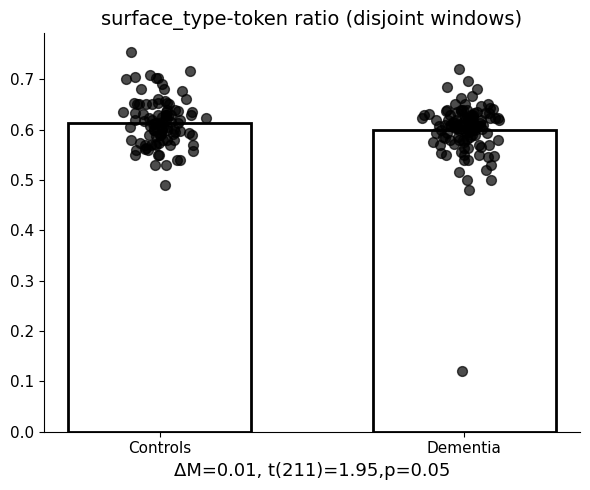

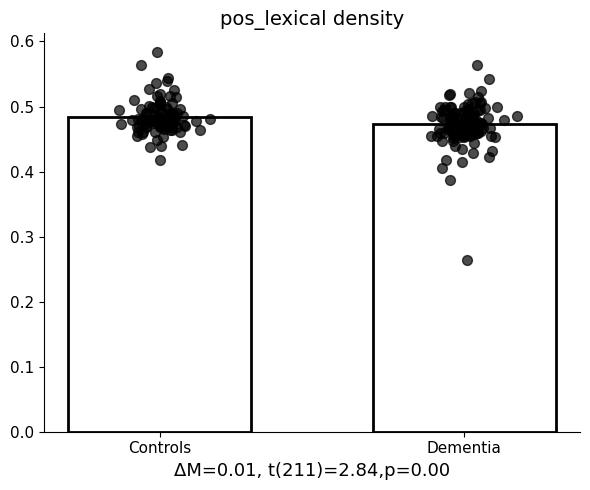

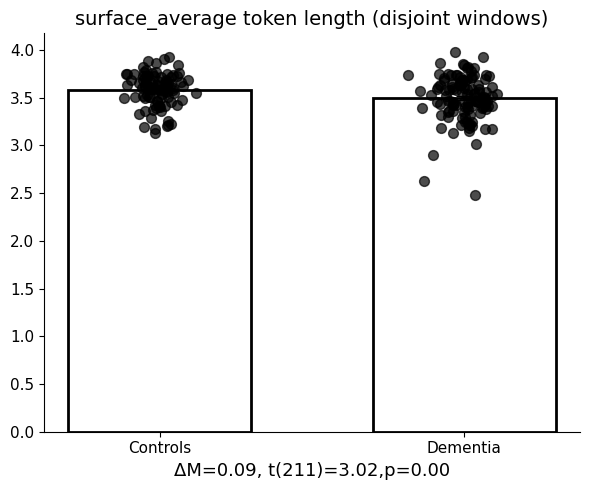

In [57]:
this_df = features_text
cols = ['surface_type-token ratio (disjoint windows)', # Decreased in Dementia
        'pos_lexical density',  # Decreased in Dementia
        'surface_average token length (disjoint windows)'# Decreased in Dementia
       ]
for i in range(len(cols)):
    key = cols[i]
    vec1=this_df[key].values[idx_controls]
    vec2=this_df[key].values[idx_patients]
    pretty_barplot(vec1,vec2,labels=('Controls', 'Dementia'),title=key)

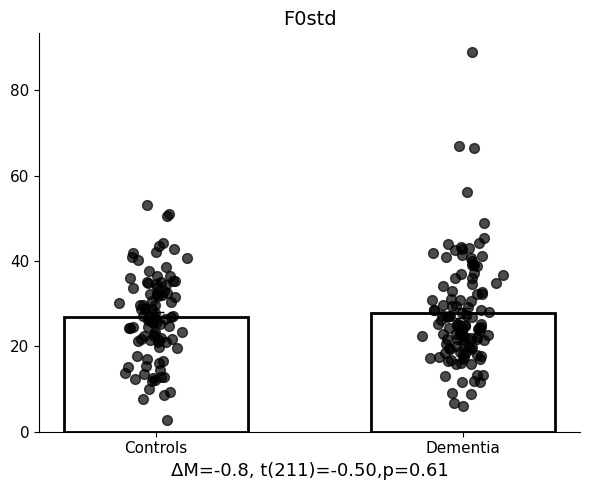

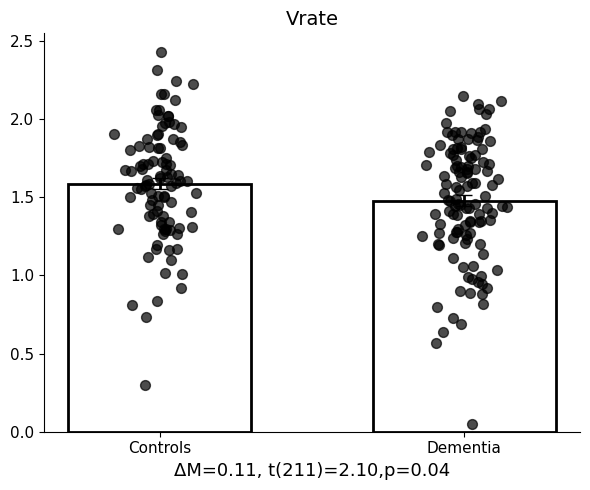

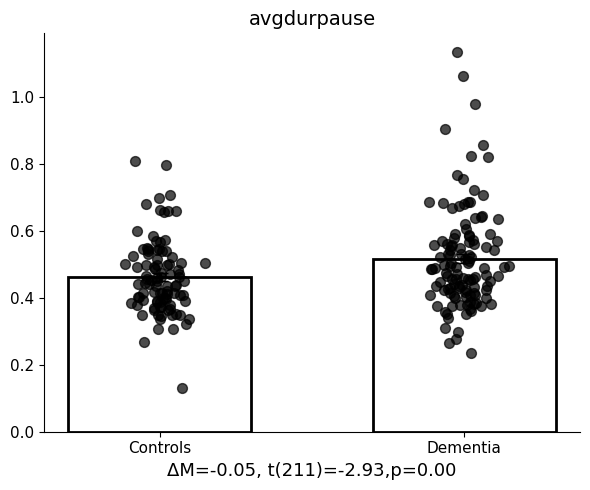

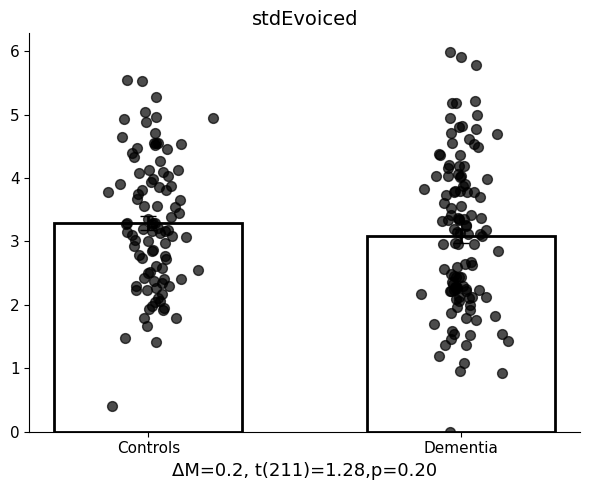

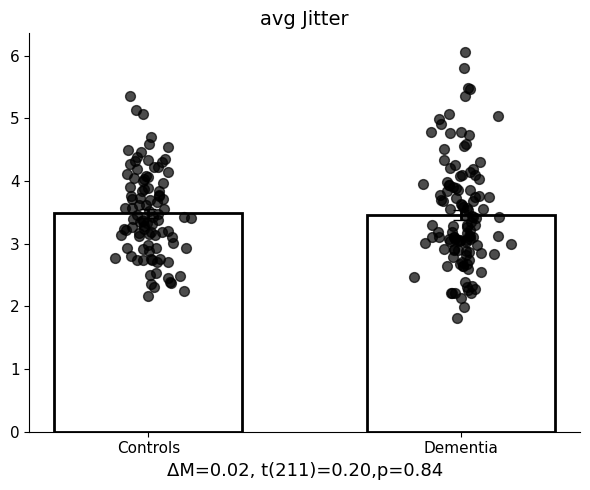

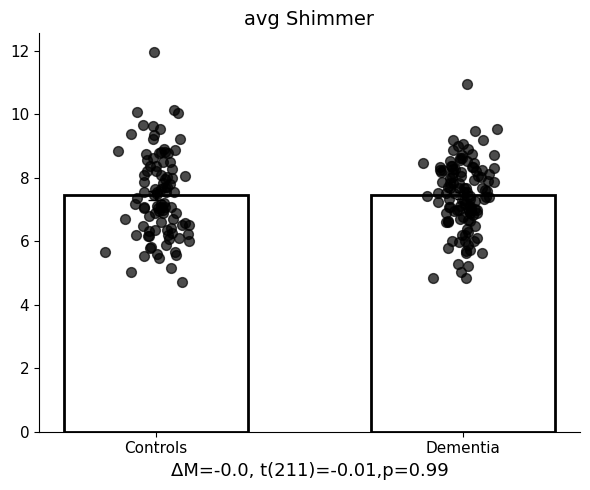

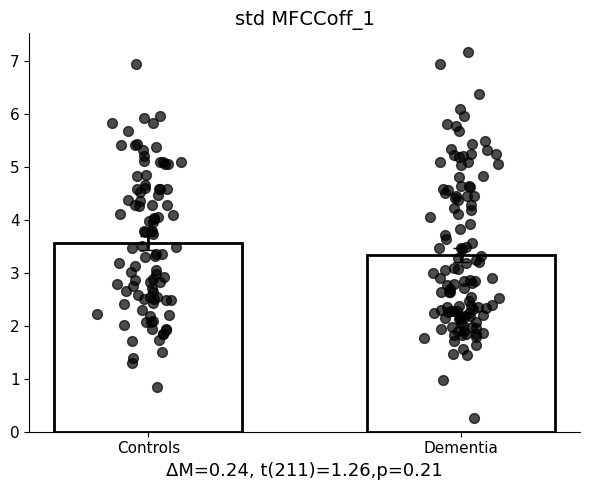

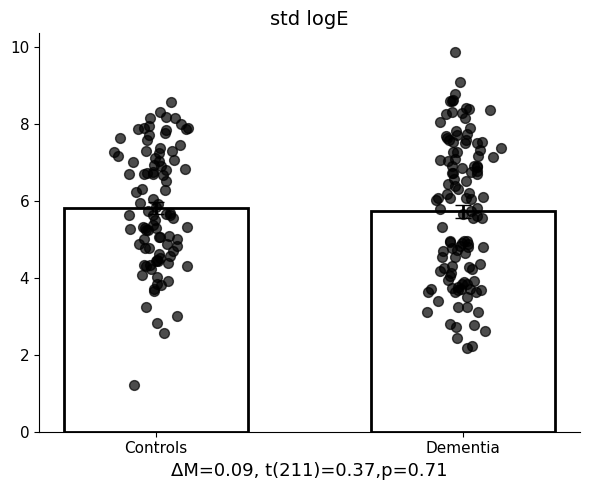

In [61]:
cols = [
    "F0std",            # reduced pitch variability (monotonic speech)
    "Vrate",            # slower speech rate
    "avgdurpause",      # longer pauses
    "stdEvoiced",       # reduced energy variability
    "avg Jitter",       # increased vocal instability
    "avg Shimmer",      # increased amplitude instability
    "std MFCCoff_1",    # spectral variability change
    "std logE"          # reduced intensity dynamics
]

this_df = features_speech
#cols = ['surface_type-token ratio (disjoint windows)','pos_lexical density','surface_average token length (disjoint windows)']
for i in range(len(cols)):
    key = cols[i]
    vec1=this_df[key].values[idx_controls]
    vec2=this_df[key].values[idx_patients]
    pretty_barplot(vec1,vec2,labels=('Controls', 'Dementia'),title=key)

In [89]:
#list(features.columns)

In [27]:
#keys = list(features.columns)

In [54]:
# for key in keys:
#     vec1=features[key].values[idx_controls]
#     vec2=features[key].values[idx_patients]
#     pretty_barplot(vec1,vec2,labels=('Control', 'Dementia'),ylabel=key)

In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score

X_text = features_text.values[:, 0:9]
X_speech = features_speech.values[:, 1::]
X = np.hstack((X_speech, X_text))
y = idx_patients.astype(int)

notnan_idx = np.isnan(X).sum(axis=1) == 0
X = X[notnan_idx, :]
y = y[notnan_idx]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=10000
    ))
])

param_grid = {
    "clf__C": np.logspace(-4, 2, 15),
    "clf__l1_ratio": np.linspace(0, 1, 8)
}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store out-of-fold predictions
y_hat = np.zeros_like(y, dtype=float)

outer_scores = []

for train_idx, test_idx in outer_cv.split(X, y):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    # Probability of class 1
    y_hat[test_idx] = grid.predict_proba(X_test)[:, 1]

    outer_scores.append(
        roc_auc_score(y_test, y_hat[test_idx])
    )

print("Nested CV AUC:", np.mean(outer_scores), "±", np.std(outer_scores))
print("y_hat shape:", y_hat.shape)

In [36]:
# from sklearn.model_selection import permutation_test_score

# score, perm_scores, pvalue = permutation_test_score(
#     pipeline,
#     X,
#     y,
#     cv=cv,
#     scoring="roc_auc",
#     n_permutations=1000,
#     n_jobs=-1
# )

# print("AUC:", score)
# print("p-value:", pvalue)